This file stores the final Long Short Term Memory (LSTM) Deep learning algorithm. The algorithm was fed with only 1 feature which is the energy consumption value (kW). The window of the LSTM is 96 rows which corresponds to 1 day. So, by seeing the data from a day before the algorithm predicts the next single data point. The performance is impressive and very comparable to ANN considering the algorithm only gets 1 feature from the dataset. In order to conduct the same style of experiments and get a comparable results between the algorithms, the data is split into 8:1:1 fashion. %80 training set, %10 validation set and %10 training set. 

In [54]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

from pandas import read_csv
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from keras.layers import LSTM, Flatten

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

#from keras.callbacks import EarlyStopping
from keras.layers import ConvLSTM2D


import ipympl 
%matplotlib ipympl

file_path = '../../Dataset/preprocessed_combined_data_weekday_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0


In [55]:
temp = pd.DataFrame(df['kW'])

display(temp)


,kW
Date Time,
2022-03-24 00:00:00,121.500
2022-03-24 00:15:00,121.500
2022-03-24 00:30:00,119.248
2022-03-24 00:45:00,120.600
2022-03-24 01:00:00,123.300
...,...
2023-03-22 22:45:00,117.448
2023-03-22 23:00:00,115.200
2023-03-22 23:15:00,118.348


In [56]:
# [[[1], [2], [3], [4], [5]]] [6]
# [[[2], [3], [4], [5], [6]]] [7]
# [[[3], [4], [5], [6], [7]]] [8]

def df_to_X_y(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [[a] for a in df_as_np[i:i+window_size,0]]
    X.append(row)
    label = df_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)

# If you want to input more than 1 feature to the LSTM use this function instead. It prepares the input to be a row of different features instead of only kW value
def df_to_X_y2(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size,0]]
    X.append(row)
    label = df_as_np[i+window_size][0]
    y.append(label)
  return np.array(X), np.array(y)

In [57]:
WINDOW_SIZE = 96
X1, y1 = df_to_X_y(temp, WINDOW_SIZE)
X1.shape, y1.shape

((34847, 96, 1), (34847, 1))

In [58]:
X_train1, y_train1 = X1[:28000], y1[:28000]
X_val1, y_val1 = X1[28000:31500], y1[28000:31500]
X_test1, y_test1 = X1[31500:], y1[31500:]
X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((28000, 96, 1),
 (28000, 1),
 (3500, 96, 1),
 (3500, 1),
 (3347, 96, 1),
 (3347, 1))

In [59]:
model1 = Sequential()
# InputLayer(Window size, feature count)
model1.add(InputLayer((WINDOW_SIZE, 1)))
model1.add(LSTM(64))
# model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 64)                16896     
                                                                 
 dense_4 (Dense)             (None, 1)                 65        
                                                                 
Total params: 16961 (66.25 KB)
Trainable params: 16961 (66.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [60]:
# cp1 = ModelCheckpoint('modelLSTM2/', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[MeanAbsoluteError()])

In [61]:
# model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp1])
model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=50)

Epoch 1/50
875/875 [==============================] - 44s 47ms/step - loss: 52309.5898 - mean_absolute_error: 187.5467 - val_loss: 19297.1621 - val_mean_absolute_error: 122.3651
Epoch 2/50
875/875 [==============================] - 39s 44ms/step - loss: 41598.3555 - mean_absolute_error: 156.5978 - val_loss: 13179.6201 - val_mean_absolute_error: 94.1876
Epoch 3/50
875/875 [==============================] - 35s 40ms/step - loss: 33862.7031 - mean_absolute_error: 129.5975 - val_loss: 8949.6826 - val_mean_absolute_error: 68.2552
Epoch 4/50
875/875 [==============================] - 35s 40ms/step - loss: 27978.3145 - mean_absolute_error: 105.5703 - val_loss: 6200.3599 - val_mean_absolute_error: 47.7527
Epoch 5/50
875/875 [==============================] - 36s 41ms/step - loss: 23387.1895 - mean_absolute_error: 91.0394 - val_loss: 4196.2524 - val_mean_absolute_error: 39.1535
Epoch 6/50
875/875 [==============================] - 34s 39ms/step - loss: 19346.6152 - mean_absolute_error: 81.1862 

Took 30 min 35 seconds to train the model

In [62]:
y_train1.shape

(28000, 1)

In [63]:
# from tensorflow.keras.models import load_model
# model1 = load_model('model1/')

train_predictions = model1.predict(X_train1).flatten()
y_train1_flattened = y_train1.flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1_flattened})
train_results

875/875 [==============================] - 19s 21ms/step


,Train Predictions,Actuals
0,153.309250,166.948
1,158.177841,168.300
2,157.903336,164.700
3,154.091644,162.448
4,153.317093,164.700
...,...,...
27995,249.943344,241.648
27996,241.672226,247.948
27997,248.284103,253.800
27998,253.409729,247.948


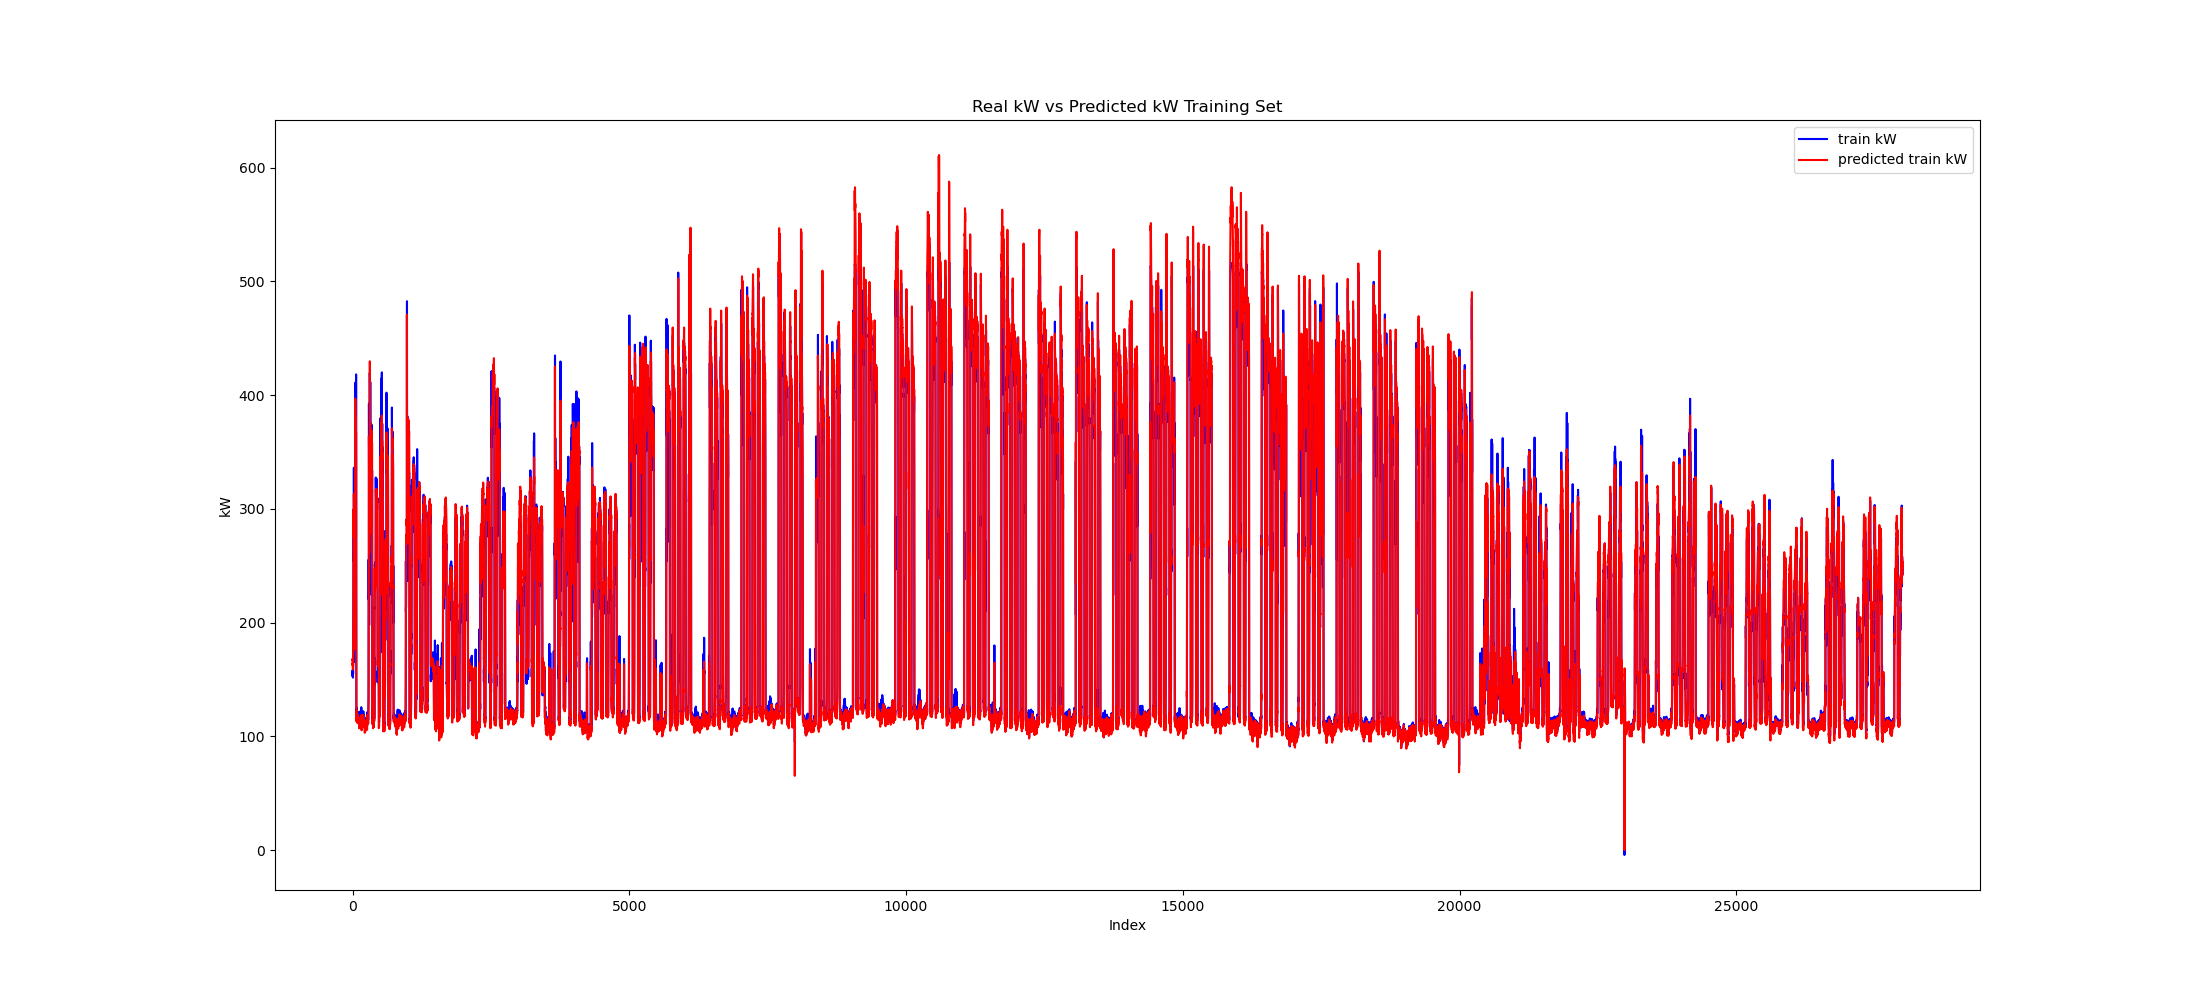

In [64]:
# import matplotlib.pyplot as plt2
plt.clf()
plt.figure(figsize=(22,10))

plt.plot(train_results['Train Predictions'], label="train kW", color="blue")
plt.plot(train_results['Actuals'], label="predicted train kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Training Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [65]:
r2_train = r2_score(train_results['Actuals'], train_results['Train Predictions'])
print("R-squared value of the training set:", r2_train)

trainMaeScore = mean_absolute_error(train_results['Actuals'], train_results['Train Predictions'])
print("MAE of the training set:", trainMaeScore)

trainMseScore = (mean_squared_error(train_results['Actuals'], train_results['Train Predictions']))
print("MSE of the training set:", trainMseScore)


R-squared value of the training set: 0.9760392550502714
MAE of the training set: 10.62205017536136
MSE of the training set: 407.726304033365


In [66]:
val_predictions = model1.predict(X_val1).flatten()
y_val1_flattened = y_val1.flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val1_flattened})
val_results

110/110 [==============================] - 3s 20ms/step


,Val Predictions,Actuals
0,247.501663,250.200
1,247.554092,235.352
2,231.067383,233.100
3,229.904572,228.600
4,226.100632,231.752
...,...,...
3495,114.819717,110.700
3496,113.883087,112.948
3497,114.890015,109.348
3498,113.128464,108.900


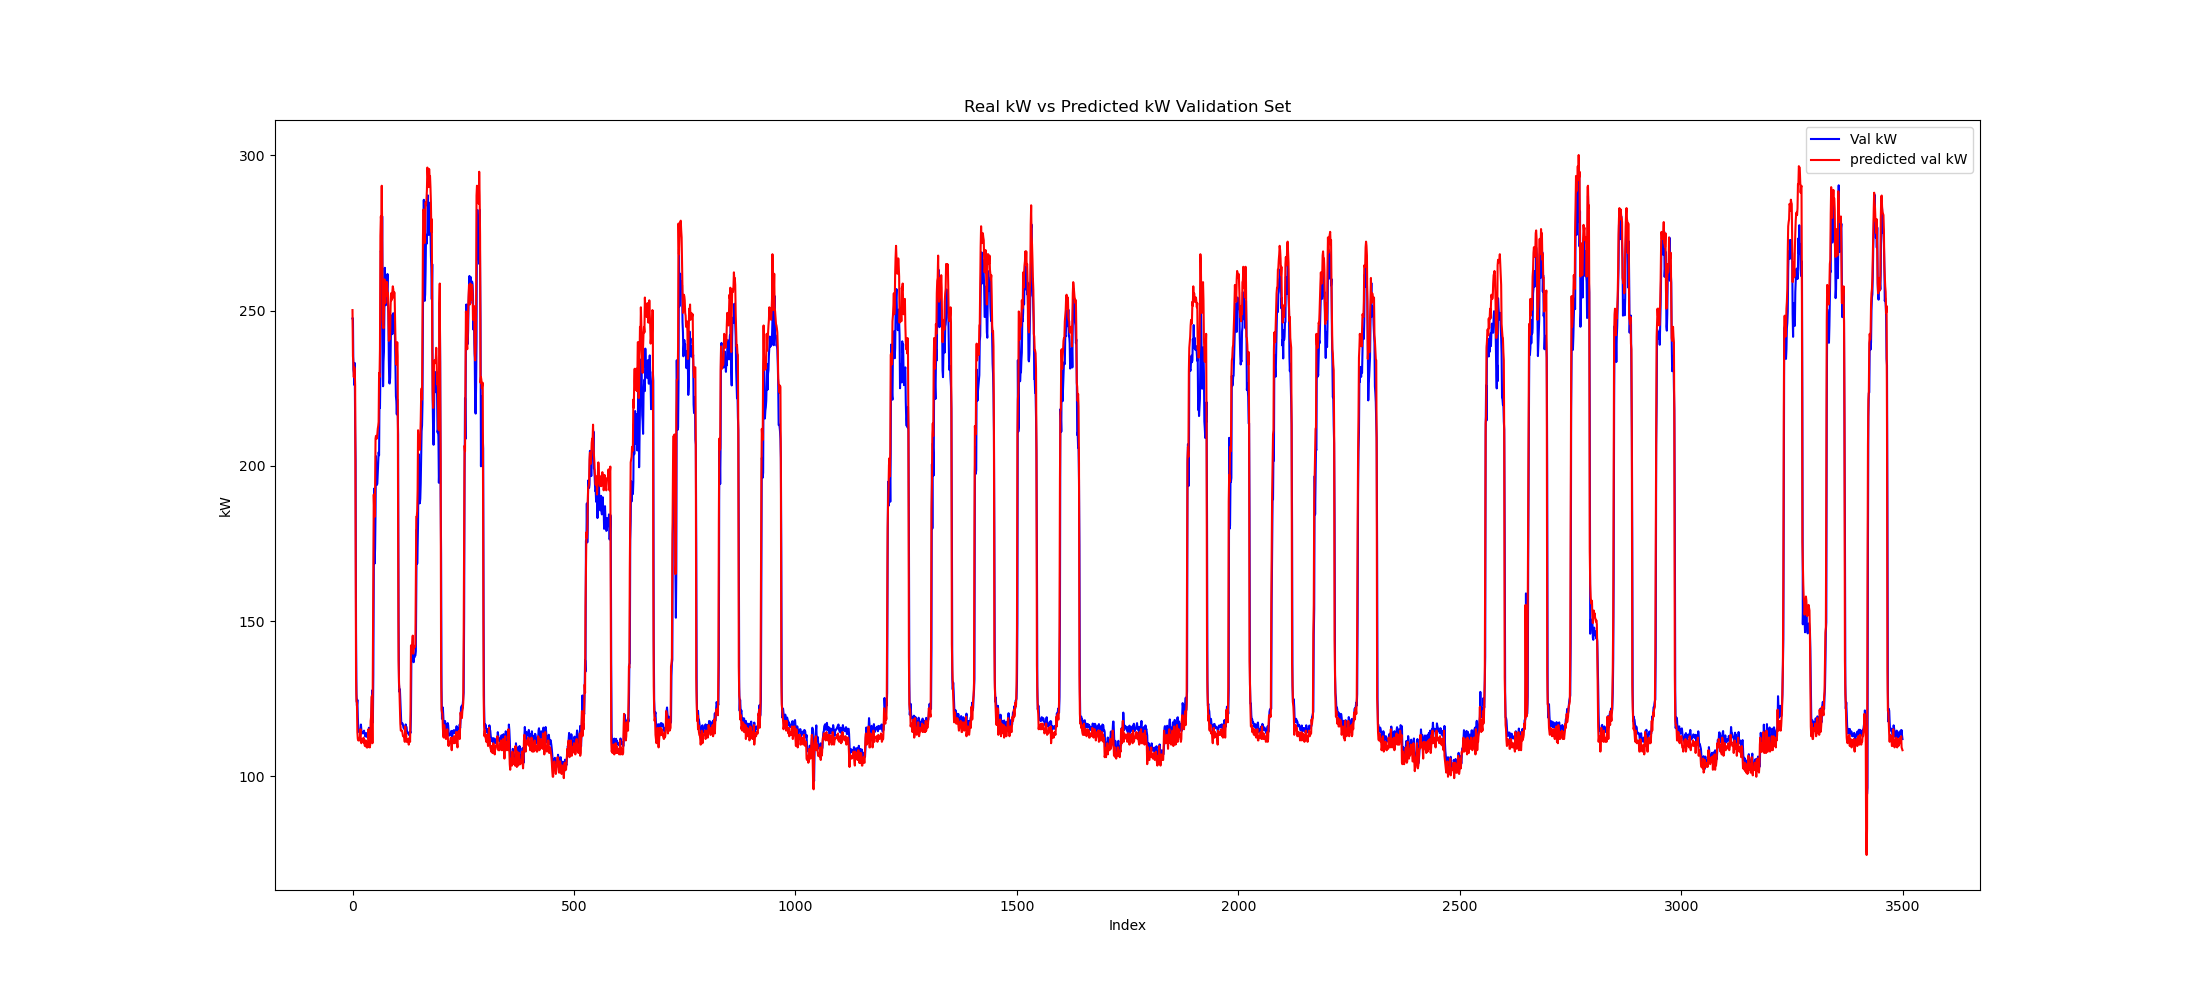

In [67]:
# import matplotlib.pyplot as plt2
# plt.clf()
plt.figure(figsize=(22,10))

plt.plot(val_results['Val Predictions'], label="Val kW", color="blue")
plt.plot(val_results['Actuals'], label="predicted val kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Validation Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [68]:
r2_val = r2_score(val_results['Actuals'], val_results['Val Predictions'])
print("R-squared value of the validation set:", r2_val)

valMaeScore = mean_absolute_error(val_results['Actuals'], val_results['Val Predictions'])
print("MAE of the validation set:", valMaeScore)

valMseScore = (mean_squared_error(val_results['Actuals'], val_results['Val Predictions']))
print("MSE of the validation set:", valMseScore)

R-squared value of the validation set: 0.9768535224808679
MAE of the validation set: 6.393690970790318
MSE of the validation set: 98.50990600529266


In [69]:
test_predictions = model1.predict(X_test1).flatten()
y_test1_flattened = y_test1.flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1_flattened})
test_results

105/105 [==============================] - 2s 20ms/step


,Test Predictions,Actuals
0,111.456375,110.248
1,112.323135,111.152
2,113.219254,110.248
3,112.969238,108.900
4,112.017967,110.700
...,...,...
3342,119.227478,117.448
3343,119.691406,115.200
3344,118.332344,118.348
3345,119.623428,116.100


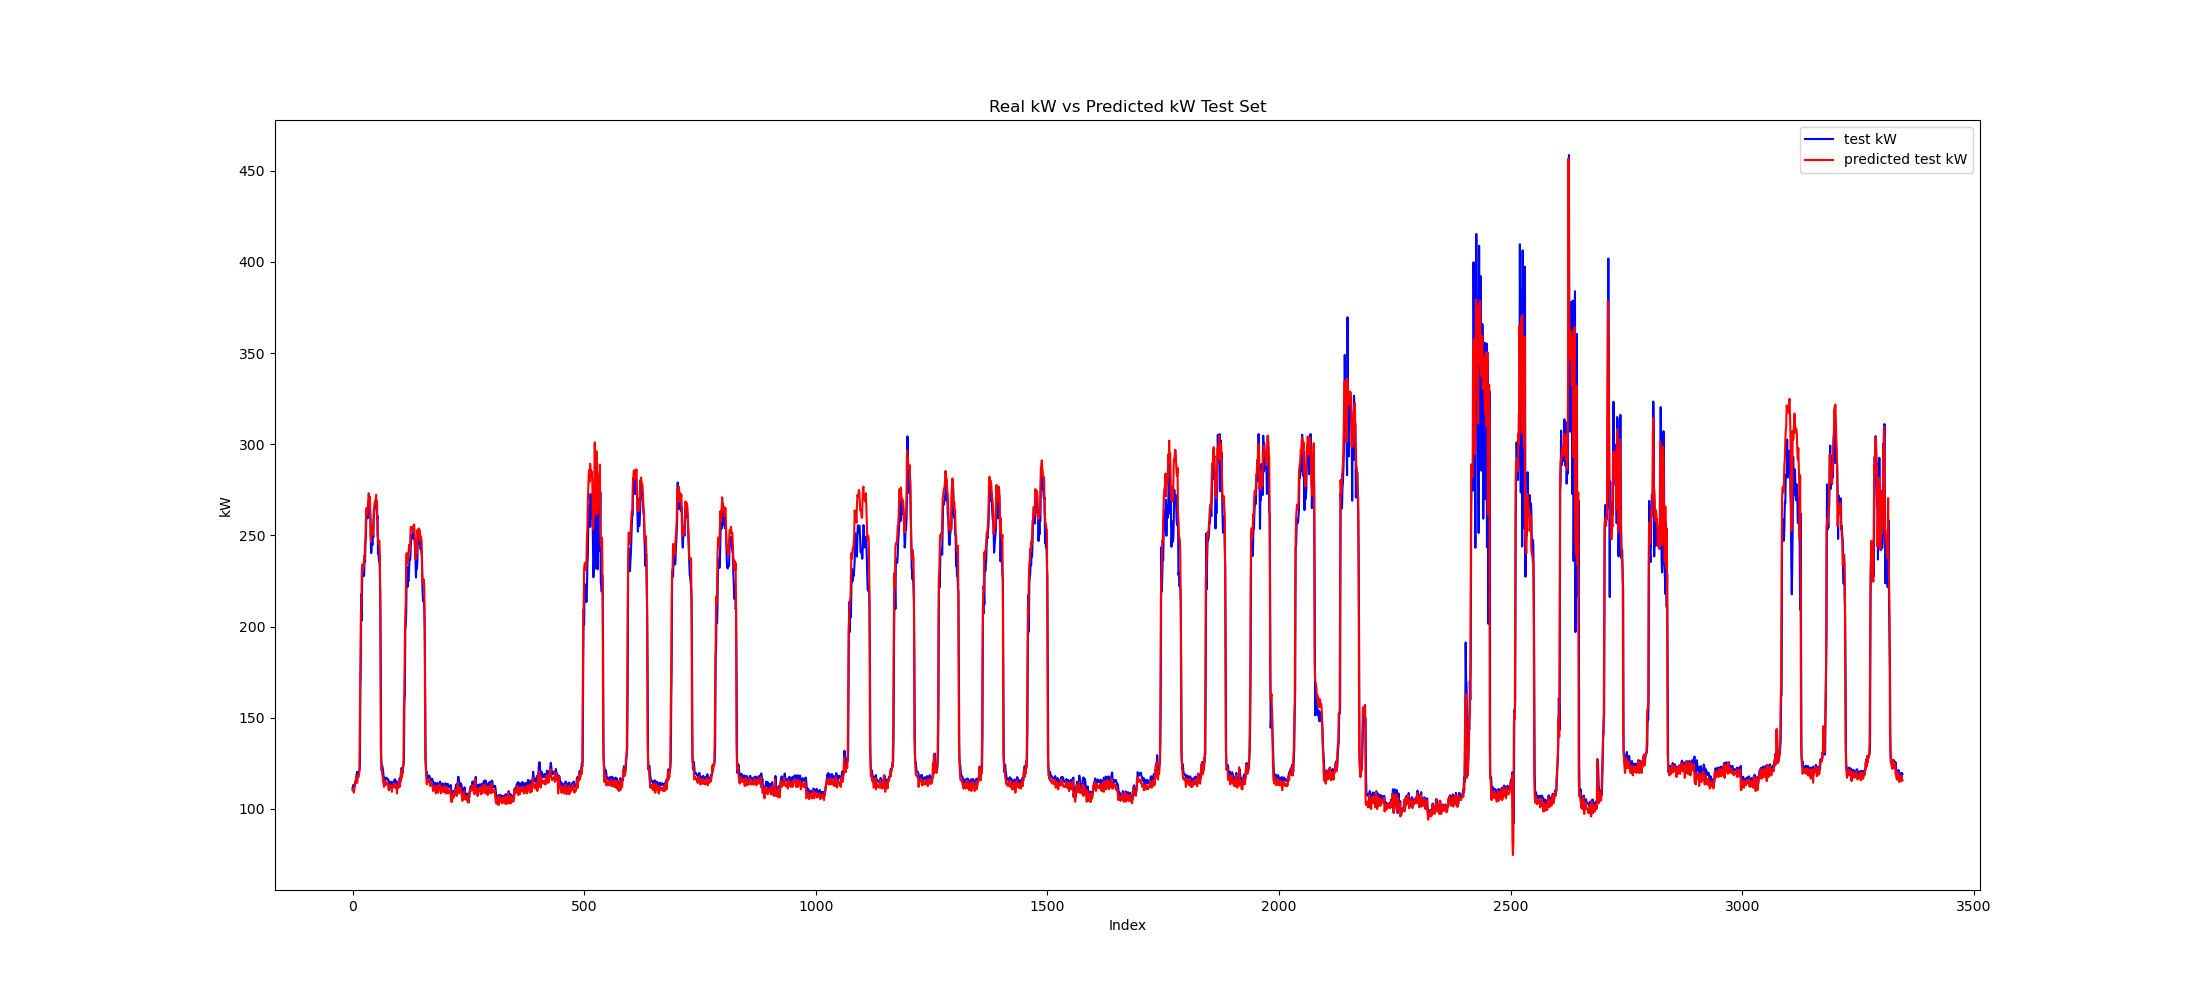

In [70]:
plt.figure(figsize=(22,10))

plt.plot(test_results['Test Predictions'], label="test kW", color="blue")
plt.plot(test_results['Actuals'], label="predicted test kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Test Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [71]:
r2_test = r2_score(test_results['Actuals'], test_results['Test Predictions'])
print("R-squared value of the test set:", r2_test)

testMaeScore = mean_absolute_error(test_results['Actuals'], test_results['Test Predictions'])
print("MAE of the test set:", testMaeScore)

testMseScore = (mean_squared_error(test_results['Actuals'], test_results['Test Predictions']))
print("MSE of the test set:", testMseScore)

R-squared value of the test set: 0.9622316362562523
MAE of the test set: 7.4809724969057525
MSE of the test set: 209.3920369762947
